In [56]:
import os
import numpy as np
import cv2
from paddleocr import PaddleOCR
import matplotlib.pyplot as plt
import time

In [57]:
start = time.perf_counter()
class MirrorMyManga:
    def __init__(self, lang="en", device="cpu", enable_mkldnn=False, use_doc_orientation_classify=False, use_doc_unwarping=False, use_textline_orientation=False) -> None:
        self.lang = lang
        self.device = device
        self.ROI = []
        self.use_doc_orientation_classify = use_doc_orientation_classify
        self.use_doc_unwarping = use_doc_unwarping
        self.use_textline_orientation = use_textline_orientation
        self.enable_mkldnn = enable_mkldnn

    def apply_ocr(self, panel):
        """
            Returns a tuple of detected text and boundary boxes in order: x_min, y_min, x_max, y_max
        """
        panel = np.asarray(panel)
        ocr = PaddleOCR(lang='en', enable_mkldnn=self.enable_mkldnn, use_doc_orientation_classify=self.use_doc_orientation_classify, use_doc_unwarping=self.use_doc_unwarping, use_textline_orientation=self.use_textline_orientation, device=self.device)
        result = ocr.predict(panel, use_doc_orientation_classify=self.use_doc_orientation_classify, use_doc_unwarping=self.use_doc_unwarping, use_textline_orientation=self.use_textline_orientation)
        bboxes = dict(result[0])['rec_boxes']
        text = dict(result[0])['rec_texts']
        return text, bboxes

    def extract_ROI(self, panel, draw_bounding_boxes=False, debug=False, return_bbox=False, color=(0, 0, 255)):
        """
            Returns the detected text as ROI(in form of NumPy array)
        """
        _, bboxes = self.apply_ocr(panel)
        ROI = []
        for bbox in bboxes:
            x_min, y_min, x_max, y_max = list(map(int, bbox))
            ROI.append(panel[y_min: y_max, x_min: x_max])
            if debug:
                print("bbox = ", bbox)
            if draw_bounding_boxes:
                panel_copy = np.asarray(panel).copy()
                panel_copy = cv2.cvtColor(panel_copy, cv2.COLOR_BGR2RGB)

                for bbox in bboxes:
                    if debug:
                        print("bbox = ", bbox)
                        print(f"x = ({x_min}, {x_max})\ny = ({y_min}, {y_max})")
                    x_min, y_min, x_max, y_max = map(int, bbox)
                    cv2.rectangle(panel_copy, pt1=(x_min, y_min), pt2=(x_max, y_max), color=color)
                #self.show(panel_copy)
        if return_bbox:
            return bboxes, ROI 
        else:
            return ROI

    def apply_page_flip(self, panel, debug=False):
        """
            Applies the flipped ROI to the to the detect text ROIs, flips the whole panel then returns the panel
        """
        panel = np.asarray(panel).copy()
        bboxes, ROI = self.extract_ROI(panel, return_bbox=True)

        #flip the detected ROIs
        ROI = list(map(np.fliplr, ROI))

        #assign the values of flipped ROIs to panel
        for roi, bbox in zip(ROI, bboxes):
            x_min, y_min, x_max, y_max = map(int, bbox)
            
            if debug:
                    print("bbox = ", bbox)
                    print(f"x = ({x_min}, {x_max})")
                    print(f"y = ({y_min}, {y_max})")

            panel[y_min: y_max, x_min: x_max] = roi
        panel = np.fliplr(panel)
        return panel

    def show(self, image):
        panel = np.asarray(image)
        plt.figure(figsize=(20, 10))
        plt.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
        plt.show()

In [58]:
panel = cv2.imread('testImage4.png')
mmm = MirrorMyManga(lang="en", device="cpu")

Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/vhvhs/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/vhvhs/.paddlex/official_models/PP-OCRv6_medium_rec`.


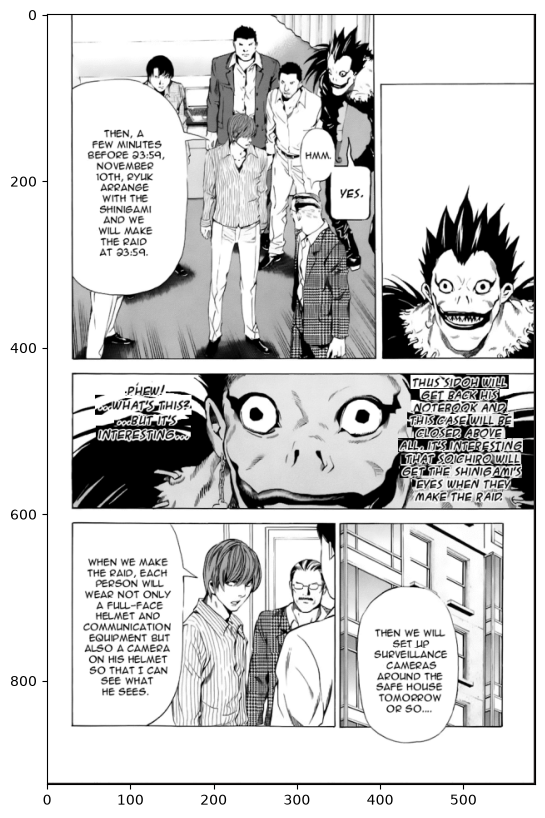

In [59]:
#ROI = mmm.extract_ROI(panel, color=(0, 0, 255))
panel = mmm.apply_page_flip(panel)

plt.figure(figsize=(20, 10))
plt.imshow(panel)
plt.show()